In [6]:
# %pip install torch torchvision torchaudio

import torch
import sys, os

from multiprocessing import Queue, Process
from torch.utils.data import ConcatDataset
from lib_train import *
# from lib_cnn import *
from lib_IGviz import *
from lib_influence_groundtruth import *
from main_vision_label_noise import *


cfg_feat = {
    'ShallowMNIST': [64,'M', 128, 'M', 128, 'MP1', 128, 'M4', 'GA'],
    'ShallowCIFAR10': [64,'M', 128, 'M', 128, 'M', 128, 'M4', 'GA'],
    'ShallowfatterMNIST': [64,'M', 128, 'M', 256, 'MP1', 512, 'M4', 'GA'],
    'ShallowfatterCIFAR10': [64,'M', 128, 'M', 256, 'M', 512, 'M4', 'GA'],

    
    'GA_VGG11': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M', 'GA'],
    'GA_VGG13': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M', 'GA'],
    'GA_VGG16': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M', 'GA'],
    'GA_VGG19': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M', 'GA'],
}

cfg_FC = {
    'ShallowMNIST': [128],
    'ShallowfatterMNIST': [512],
    
    'ShallowCIFAR10': [128],
    'ShallowfatterCIFAR10': [512],
    
    'GA_VGG11': [512],
    'GA_VGG13': [512],
    'GA_VGG16': [512],
    'GA_VGG19': [512],
}


class CNN(nn.Module):
    def __init__(self, vgg_name, in_channels=1, num_classes=10, img_size=32, batchnorm=True):
        super(CNN, self).__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.batchnorm = batchnorm

        # Build convolutional feature extractor
        self.features, out_channels = self._make_layers(cfg_feat[vgg_name])

        # Dynamically compute flattened feature size
        flatten_size = self._get_flatten_size(img_size, out_channels)

        print('flatten_size:', flatten_size)

        # Build classifier
        self.classifier = self._make_FC(flatten_size, cfg_FC[vgg_name])
        
    def forward(self, x):
        out = self.features(x)
        out = out.view(out.size(0), -1)
        out = self.classifier(out)
        return out

    def _get_flatten_size(self, img_size, out_channels):
        """
        Pass dummy input to compute size of flattened feature map.
        """
        dummy_input = torch.zeros(1, self.in_channels, img_size, img_size)

        # Switch to eval mode to avoid BatchNorm error
        was_training = self.features.training
        self.features.eval()
        with torch.no_grad():
            dummy_output = self.features(dummy_input)

        # Restore original mode
        if was_training: self.features.train()

        print(dummy_output.shape)

        print('With change:', dummy_output.size(1))
        print('No change:', dummy_output.view(1, -1).size(1))
    
        # If AdaptiveAvgPool2d was applied, the feature map size will be 1x1
        if dummy_output.dim() == 4 and dummy_output.shape[2:] == (1, 1):
            print('Has GlobalAvg')
            return dummy_output.size(1)  # Only channels
        else:
            return dummy_output.view(1, -1).size(1)  # Flatten all dims

    def _make_layers(self, cfg):
        layers = []
        in_channels = self.in_channels
        for x in cfg:
            if type(x) != int:
                if x[0] == 'M':
                    if len(x)==1:
                        layers += [nn.MaxPool2d(kernel_size=2)]
                    else:
                        kernel_size = 2
                        padding = 0 
                        if x[1].isnumeric():
                            kernel_size = int(x[1])
                            if len(x)>2:
                                padding = int(x[3])
                        else:
                            padding = int(x[2])
                        layers += [nn.MaxPool2d(kernel_size=kernel_size, padding=padding)]
                        
            elif x == 'GA':
                layers += [nn.AdaptiveAvgPool2d((1, 1))]
                
            else:
                if self.batchnorm: 
                    layers += [nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                               nn.BatchNorm2d(x),
                               nn.ReLU(inplace=True)]
                else:
                    layers += [nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                               nn.ReLU(inplace=True)]
                in_channels = x
                
        return nn.Sequential(*layers), in_channels
    
    def _make_FC(self, in_channels, cfg):
        layers = []
        for i in range(len(cfg)):
            if self.batchnorm:
                layers += [nn.Linear(in_channels, cfg[i]),
                           nn.BatchNorm1d(cfg[i]),
                           nn.ReLU(inplace=True)]
            else:
                layers += [nn.Linear(in_channels, cfg[i]),
                           nn.ReLU(inplace=True)]
                
            in_channels = cfg[i]
        layers += [nn.Linear(in_channels, self.num_classes)]
        return nn.Sequential(*layers)

In [7]:
# -------------- Device Setup --------------
DEVICE = torch.device('cuda')
if not torch.cuda.is_available():
    print("WARN: Cuda unavailable, defaulting to cpu...")
print(f"Using device: {DEVICE}")


# -------------- Initialize arguments --------------
dataset       = 'Flowers102'
model_name    = 'GA_VGG16'
root_folder   = '../data'
program_mode  = 'normal' # normal or GT (Ground truth)
save_mode     = 'store' # store, load or none
visualize     = False
noise_type    = 'symmetric'
noise_level   = 0
num_workers   = 0
img_size      = 224
log_verbosity = 1

# -------------- Start logger queue and listener process --------------
log_queue = Queue()
listener = Process(target=log_listener, args=(log_queue, 1))
listener.start()

logger = InfluenceLogger(log_queue, verbose=log_verbosity)
logger.log("Main process started.", level=1)


labelnoise_params = {
    'noise_type':  noise_type,
    'noise_level': noise_level
}
loader_params = {
    'dataset_name':     dataset,
    'conversion':       'none',
    'root_folder':      root_folder,
    'training_size':    'full', # 'full'
    'batch_size':       20,   # 20-40
    'IG_batch_size':    400, 
    'transform':        None,
    'add_singleton':    False,
    'convert_to_torch': False,
    'num_workers':      num_workers,
}
influence_params = {
    'loss_scaling_span':  'full', # 'batch' or 'full'
    'loss_scaling_type':  'root_mean_squared', # 'mean' or 'mean_absolute' or None
    'set_zero_mean':      False, # 'full' or 'separate'
    'class_normalize' :   False,
    'remove_negatives' :  False,
    'clipping' :          False,
    'intraclass_only' :   True,
    'negative_clipping':  False,
    'clip_outliers':      False,
    'mode':               'mean', # For InfluenceGraphv3
    'gradient_lr':        0.1, # For InfluenceGraphv3
    'dtype':              np.float32,
    'graph_type':         InfluenceGraphv4,
}
train_params = {
    'optimizer':           'Adam',
    'scheduler':           {'name': None}, # 'step_size': 10, 'milestones':[10,20,30],'gamma':0.8, 'max_lr': 0.01}
    'init_rate':           0.0005,
    'total_epochs':        20,
    'weight_decay':        0, 
    'criterion':           'CrossEntropyLoss',
    'disp_epoch':          True,
    'disp_loss_epoch':     False,
    'disp_time_per_epoch': True, 
    'disp_loss_final':     True, 
    'disp_accuracy_final': True
}
influence_GT_params = {
    'type':                'batch', # batch or representative
    'training_iterations': train_params['total_epochs'],
    'intraclass_only':     True,
    'dtype':               np.float32,
}
influence_GT_train_params = {
    'optimizer':           'SGD',
    'scheduler':           {'name': None}, # 'step_size': 10, 'milestones':[10,20,30],'gamma':0.8, 'max_lr': 0.01}
    'init_rate':           0.1,
    'total_epochs':        50,
    'weight_decay':        0, 
    'criterion':           'CrossEntropyLoss',
    'disp_epoch':          False,
    'disp_loss_epoch':     True,
    'disp_time_per_batch': True,
    'disp_total_time':     True,
}
model_params = {
    'type':                CNN,
    'name':                model_name,
    'in_channels':         1,
    'num_classes':         10,
    'img_size':            img_size,
    'batchnorm':           True,
}

# -------------- Customize arguments based on model --------------
if dataset == 'MNIST' or dataset == 'FashionMNIST':
    model_params['in_channels'] = 1
    model_params['num_classes'] = 10

elif dataset == 'CIFAR10':
    model_params['in_channels'] = 3
    model_params['num_classes'] = 10

elif dataset == 'Flowers102':
    model_params['in_channels'] = 3
    model_params['num_classes'] = 102


model = model_params['type'](
    model_params['name'],
    in_channels = model_params['in_channels'],
    num_classes = model_params['num_classes'],
    img_size    = model_params['img_size'],
    batchnorm   = model_params['batchnorm']
)

Using device: cuda
[2025-07-18 07:34:42] (+0.00s) [PID 10313] [MainProcess] Main process started.
torch.Size([1, 512, 7, 7])
With change: 512
No change: 25088
flatten_size: 25088
[2025-07-18 07:35:32] (+50.55s) [PID 10313] [MainProcess] Training model generally with total params: 27622054...
[2025-07-18 07:35:33] (+51.02s) [PID 10313] [MainProcess] Starting epoch: 0...


In [4]:
model

CNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

In [8]:
def genloaders_vision_test(loader_params, labelnoise_params, image_size=(224, 224)):

    def preprocess_dataset(dataset, transform=None, is_grayscale=False):
        
        if isinstance(dataset.data, np.ndarray):
            data = torch.from_numpy(dataset.data)
        else:
            data = dataset.data  # Already a torch.Tensor

        data = data.float() / 255.0

        if is_grayscale:
            data = data.unsqueeze(1)  # Add channel dim for grayscale: [N, 1, H, W]
        else:
            data = data.permute(0, 3, 1, 2)  # [N, H, W, C] → [N, C, H, W]

        targets = torch.tensor(dataset.targets)
        return data_resized, targets

    def preprocess_dataset_from_imagefolder(dataset, transform=None):
        data = []
        targets = []

        for img, label in dataset:
            if transform:
                img = transform(img)
            data.append(img)
            targets.append(label)

        data = torch.stack(data)
        targets = torch.tensor(targets)
        return data, targets

    dataset_name = loader_params['dataset_name']
    root         = loader_params['root_folder']
    is_grayscale = False

    # Default transforms
    normalize_imagenet = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    train_transform = transforms.Compose([
        transforms.Resize(image_size),
        # transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
        # transforms.RandomHorizontalFlip(),
        # transforms.RandomRotation(20),
        transforms.ToTensor(),
        # normalize_imagenet,
    ])

    test_transform = transforms.Compose([
        transforms.Resize(image_size),
        # transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        normalize_imagenet,
    ])

    # Simplify for grayscale datasets
    if dataset_name in ['MNIST', 'FashionMNIST']:
        is_grayscale = True
        train_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            # transforms.Normalize((0.5,), (0.5,))
        ])
        test_transform = train_transform
    
    ############################## Load relevant datasets ##############################
    
    if dataset_name == 'FashionMNIST':
        train = torchvision.datasets.FashionMNIST(root=root, train=True, download=True)
        test = torchvision.datasets.FashionMNIST(root=root, train=False, download=True)
    
    elif dataset_name == 'MNIST':
        train = torchvision.datasets.MNIST(root=root, train=True, download=True)
        test = torchvision.datasets.MNIST(root=root, train=False, download=True)

    elif dataset_name == 'CIFAR10':
        train = torchvision.datasets.CIFAR10(root=root, train=True, download=True)
        test = torchvision.datasets.CIFAR10(root=root, train=False, download=True)

    elif dataset_name == 'CIFAR100':
        train = torchvision.datasets.CIFAR100(root=root, train=True, download=True)
        test = torchvision.datasets.CIFAR100(root=root, train=False, download=True)

    ############################## Additional fine grained datasets ##############################
    
    elif dataset_name == 'Flowers102':
        flowers_train = torchvision.datasets.Flowers102(root=root, split='train', download=True)
        flowers_val   = torchvision.datasets.Flowers102(root=root, split='val', download=True)
        flowers_test  = torchvision.datasets.Flowers102(root=root, split='test', download=True)

        # Use original test split as new train dataset (6149 images)
        train = flowers_test
        # Combine train + val into one test dataset (2040 images)
        test = ConcatDataset([flowers_train, flowers_val])

    elif dataset_name == 'FGVCAircraft':
        train = torchvision.datasets.FGVCAircraft(root=root, split='train', download=True)
        trainval = torchvision.datasets.FGVCAircraft(root=root, split='trainval', download=True)
        val  = torchvision.datasets.Flowers102(root=root, split='val', download=True)
        test = torchvision.datasets.FGVCAircraft(root=root, split='test', download=True)

    elif dataset_name == 'SVHN':
        train = torchvision.datasets.SVHN(root=root, split='train', download=True)
        test = torchvision.datasets.SVHN(root=root, split='test', download=True)
        extra = torchvision.datasets.SVHN(root=root, split='extra', download=True)

    else:
        print("ERROR: Unknown dataset:", dataset_name)


    dataset_data, dataset_targets = None, None
    dataset_test_data, dataset_test_targets = None, None
    
    if dataset_name in ['FashionMNIST', 'MNIST', 'CIFAR10', 'CIFAR100']:
        dataset_data, dataset_targets = preprocess_dataset(
            train,
            transform=train_transform,
            is_grayscale=is_grayscale
        )
        dataset_test_data, dataset_test_targets = preprocess_dataset(
            test,
            transform=test_transform,
            is_grayscale=is_grayscale
        )
        
    else:
        dataset_data, dataset_targets = preprocess_dataset_from_imagefolder(train, transform=train_transform)
        dataset_test_data, dataset_test_targets = preprocess_dataset_from_imagefolder(test, transform=test_transform)

    ############################## Apply Label Noise ##############################
    if labelnoise_params['noise_type'] is not None and labelnoise_params['noise_level'] > 0.0:
        num_classes = len(torch.unique(dataset_targets))
        dataset_targets = add_label_noise(
            dataset_targets,
            labelnoise_params['noise_type'], 
            labelnoise_params['noise_level'],
            num_classes
        )

    ############################## Generate DataLoaders ##############################
    trainloader, testloader, IG_trainloader = genloaders(
        dataset_data,
        dataset_targets,
        dataset_test_data,
        dataset_test_targets,
        loader_params
    )
        
    return trainloader, testloader, IG_trainloader


image_size = (img_size, img_size)
trainloader, testloader, IG_trainloader = genloaders_vision_test(loader_params, labelnoise_params, image_size=image_size)

In [ ]:
model = train_model_general(
    model,
    trainloader,
    train_params,
    logger=logger
)

print( 'Train accuracy:', test_model(model, trainloader) )
print( 'Test accuracy:', test_model(model, testloader) )

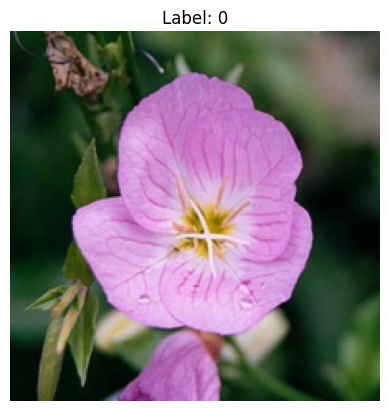

In [21]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# Get one batch from trainloader
dataiter = iter(trainloader)
images, labels, indices = next(dataiter)  # unpack your dataloader

# Select the first image from the batch
img_tensor = images[0]  # shape: [C, H, W]

# Convert tensor to PIL image
to_pil = transforms.ToPILImage()
pil_img = to_pil(img_tensor)

# (Optional) show inline if using Jupyter Notebook
plt.imshow(pil_img)
plt.title(f"Label: {labels[0]}")
plt.axis('off')
plt.show()